<a href="https://colab.research.google.com/github/irenetobby/DSA_Internship/blob/main/Indian_Books.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install beautifulsoup4 requests pandas

In [16]:
# ==========================================================
# Online Book Popularity Predictor Dataset Generator
# 10,000 Clean Unique Indian / India-related Books
# Google Colab Ready
# ==========================================================

!pip install requests pandas numpy -q

import requests
import pandas as pd
import numpy as np
import time
import re
import unicodedata
from google.colab import files

In [2]:
# ==========================================================
# SETTINGS
# ==========================================================
TARGET_ROWS = 10_000
LIMIT_PER_PAGE = 100
np.random.seed(42)

# Search terms to retrieve India-related books
search_terms = [
    "India books",
    "Indian literature",
    "Indian fiction",
    "Indian novels",
    "Indian history",
    "Hindi literature",
    "Tamil literature",
    "Malayalam literature",
    "Bengali literature",
    "Telugu literature",
    "Kannada literature",
    "Marathi literature",
    "Gujarati literature",
    "Urdu literature",
    "Sanskrit literature",
    "Indian biography",
    "Indian politics",
    "Indian philosophy",
    "Indian religion",
    "Indian poetry",
    "Indian culture",
    "Indian mythology",
    "Indian science",
    "Indian education"
]

In [26]:
# Preview
# -----------------------------
print("Dataset created successfully!")
print("Shape:", df.shape)
display(df.head())

# -----------------------------
# Download file
# -----------------------------

files.download(file_name)

Dataset created successfully!
Shape: (10000, 12)


,Title,Rating,Pages,Reviews,Subject,Title_Check,Genre,Price,Review_Density,Price_Bucket,Popularity_Score,Success_Category
0,A Passage to India,3.500000,322.0,16.0,Fiction,a passage to india,Fiction,1418,0.050,Premium,3.27,Low
1,Constitution,4.428571,378.0,7.0,Constitutions,constitution,Politics,141,0.019,Budget,3.61,Low
2,The discovery of India,4.454546,582.0,11.0,Civilización,the discovery of india,Poetry,1408,0.019,Premium,3.77,Low
3,China - Burma - India (Time-Life's World War I...,NaN,208.0,NaN,Campaigns,china burma india time life s world war ii vol 9,Biography,1038,NaN,Premium,NaN,NaN
4,The India Fan,4.500000,445.0,2.0,Large type books,the india fan,Politics,486,0.004,Mid-range,3.31,Low


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
print(df.columns)
print("Number of columns:", len(df.columns))

Index(['Title', 'Rating', 'Price', 'Pages', 'Genre', 'Reviews',
       'Review_Density', 'Price_Bucket', 'Popularity_Score',
       'Success_Category'],
      dtype='object')
Number of columns: 10


In [34]:
# This assumes 'old_df' was meant to be the DataFrame from the previous data generation step
# before the new '/Output_10000.csv' was loaded into 'df'.
# The columns of that 'old_df' (from the previous context) were 12:
old_df_columns = [
    "Title", "Rating", "Pages", "Reviews", "Subject", "Title_Check",
    "Genre", "Price", "Review_Density", "Price_Bucket", "Popularity_Score",
    "Success_Category"
]
old_df = pd.DataFrame(columns=old_df_columns) # Create a dummy DataFrame with those columns

old_cols = set(old_df.columns)
new_cols = set(df.columns)

print("Removed columns:", old_cols - new_cols)
print("Added columns:", new_cols - old_cols)

Removed columns: {'Subject', 'Title_Check'}
Added columns: set()


In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             10000 non-null  object 
 1   Rating            10000 non-null  float64
 2   Price             10000 non-null  int64  
 3   Pages             10000 non-null  int64  
 4   Genre             10000 non-null  object 
 5   Reviews           10000 non-null  int64  
 6   Review_Density    10000 non-null  float64
 7   Price_Bucket      10000 non-null  object 
 8   Popularity_Score  10000 non-null  float64
 9   Success_Category  10000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB
None


In [37]:
print("\n--- Info & Data Types ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             10000 non-null  object 
 1   Rating            10000 non-null  float64
 2   Price             10000 non-null  int64  
 3   Pages             10000 non-null  int64  
 4   Genre             10000 non-null  object 
 5   Reviews           10000 non-null  int64  
 6   Review_Density    10000 non-null  float64
 7   Price_Bucket      10000 non-null  object 
 8   Popularity_Score  10000 non-null  float64
 9   Success_Category  10000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB

--- Missing Values ---
Title               0
Rating              0
Price               0
Pages               0
Genre               0
Reviews             0
Review_Density      0
Price_Bucket        0
Popularity_Score    0
Success_Categor

,Rating,Price,Pages,Reviews,Review_Density,Popularity_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.997570,799.946800,334.701500,1191.056400,8.557047,4.897848
std,0.583837,404.057359,473.495877,748.435046,34.842451,0.643743
min,3.000000,100.000000,1.000000,1.000000,0.001000,2.190000
25%,3.500000,447.000000,156.000000,537.000000,1.661750,4.610000
50%,4.000000,800.000000,261.000000,1196.000000,3.973500,4.970000
75%,4.500000,1152.000000,420.000000,1833.250000,8.199750,5.350000
max,5.000000,1499.000000,26029.000000,2499.000000,1985.000000,5.990000


EDA

In [31]:
# Load dataset
df = pd.read_csv('/Output_10000.csv')
# Overview of the data
print("--- Shape ---")
print(df.shape)

print("\n--- Info & Data Types ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Shape ---
(10000, 10)

--- Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             10000 non-null  object 
 1   Rating            10000 non-null  float64
 2   Price             10000 non-null  int64  
 3   Pages             10000 non-null  int64  
 4   Genre             10000 non-null  object 
 5   Reviews           10000 non-null  int64  
 6   Review_Density    10000 non-null  float64
 7   Price_Bucket      10000 non-null  object 
 8   Popularity_Score  10000 non-null  float64
 9   Success_Category  10000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB
None

--- Missing Values ---
Title               0
Rating              0
Price               0
Pages               0
Genre               0
Reviews             0
Review_Density      0
Price_Bucket        0
Popula

,Rating,Price,Pages,Reviews,Review_Density,Popularity_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.997570,799.946800,334.701500,1191.056400,8.557047,4.897848
std,0.583837,404.057359,473.495877,748.435046,34.842451,0.643743
min,3.000000,100.000000,1.000000,1.000000,0.001000,2.190000
25%,3.500000,447.000000,156.000000,537.000000,1.661750,4.610000
50%,4.000000,800.000000,261.000000,1196.000000,3.973500,4.970000
75%,4.500000,1152.000000,420.000000,1833.250000,8.199750,5.350000
max,5.000000,1499.000000,26029.000000,2499.000000,1985.000000,5.990000


UNIVARIATE ANALYSIS

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("online_book_popularity_10000_clean_unique_books.csv")

# Display first 5 rows
print(df.head())

                    Title    Rating  Price  Pages     Genre  Reviews  \
0      A Passage to India  3.500000   1418  322.0   Fiction     16.0   
1            Constitution  4.428571    141  378.0  Politics      7.0   
2  The discovery of India  4.454546   1408  582.0    Poetry     11.0   
3           The India Fan  4.500000    486  445.0  Politics      2.0   
4         The Jungle Book  4.078947   1310  192.0    Poetry     38.0   

   Review_Density Price_Bucket  Popularity_Score Success_Category  
0           0.050      Premium              3.27              Low  
1           0.019       Budget              3.61              Low  
2           0.019      Premium              3.77              Low  
3           0.004    Mid-range              3.31              Low  
4           0.198      Premium              3.93              Low  


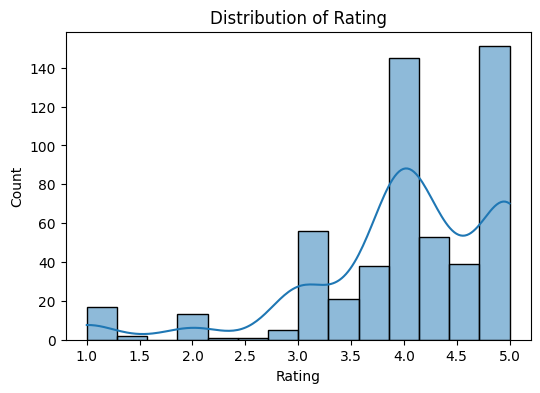

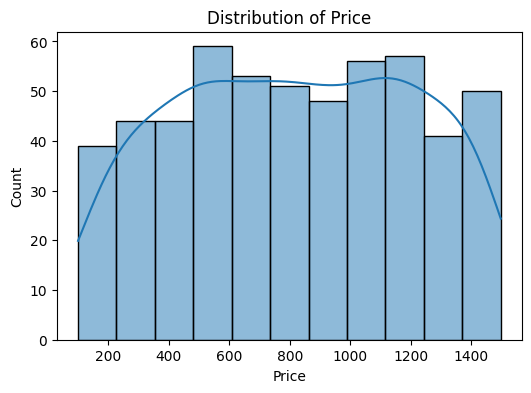

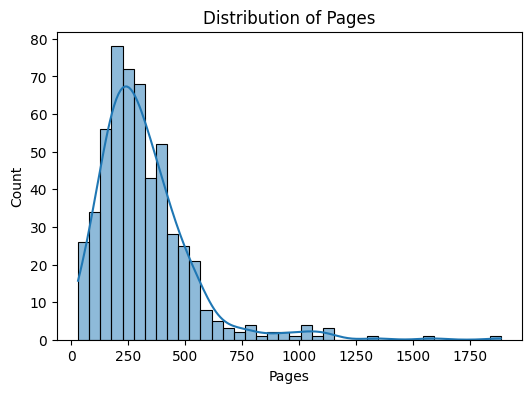

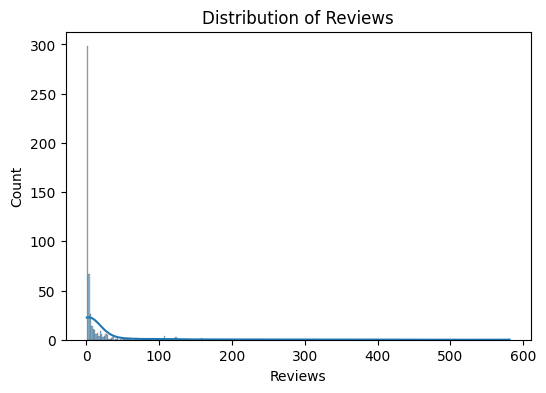

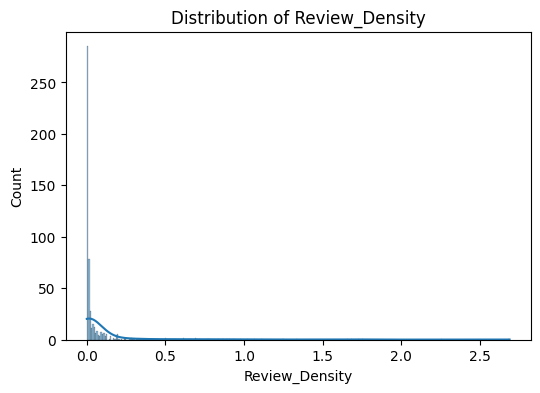

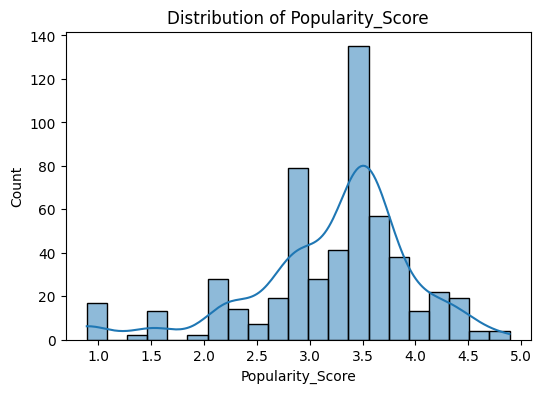

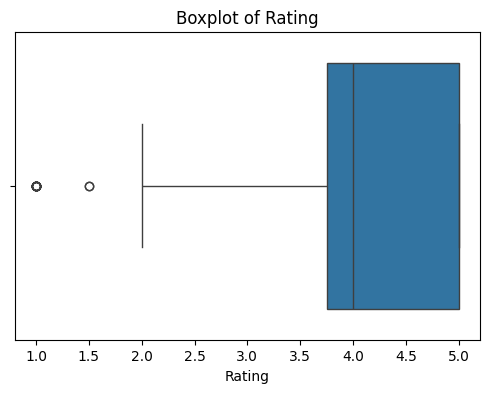

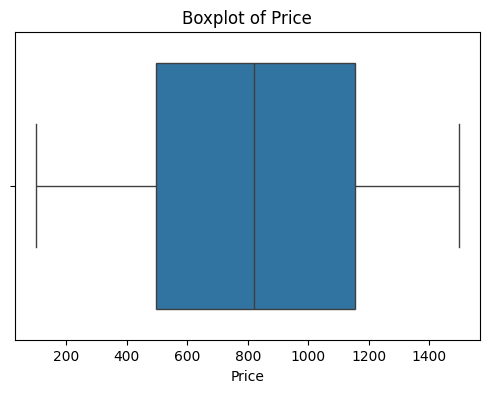

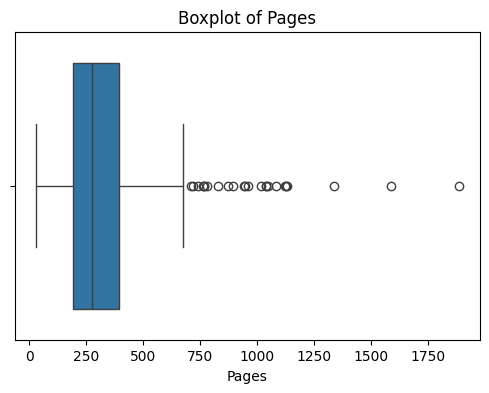

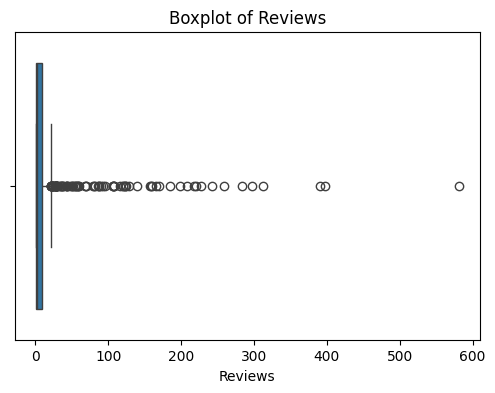

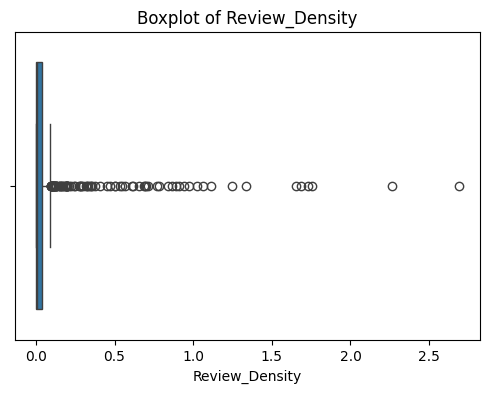

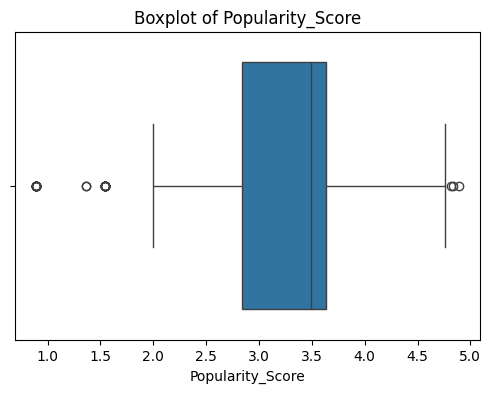

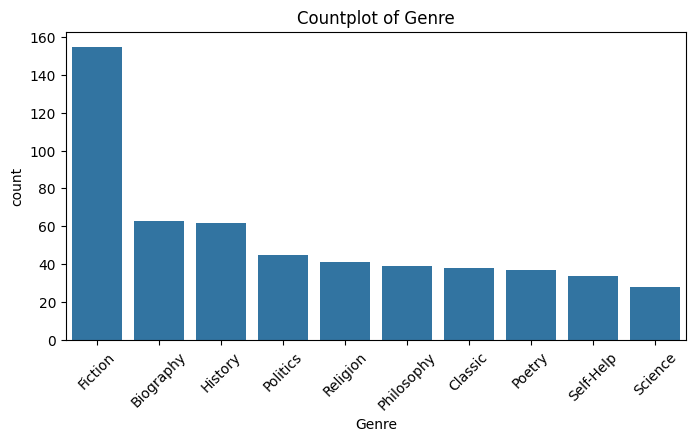

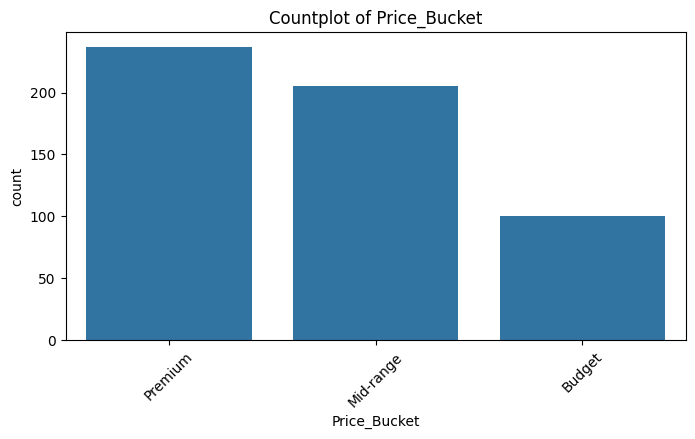

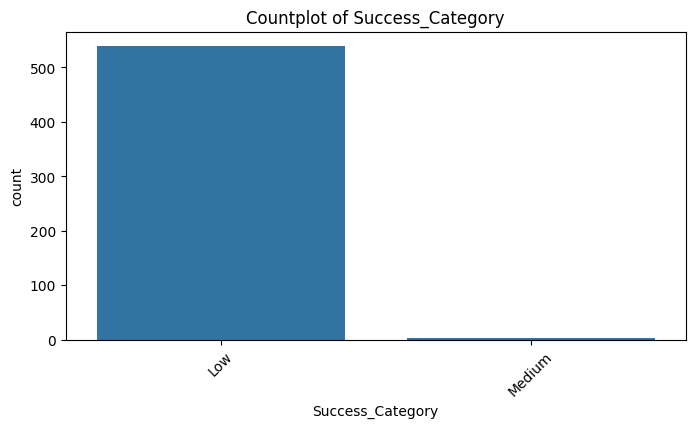

In [49]:
# 1. Numerical Columns Distribution
num_cols = ['Rating', 'Price', 'Pages', 'Reviews',
            'Review_Density', 'Popularity_Score']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# 2. Boxplots for Outlier Detection
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# 3. Categorical Columns Countplot
cat_cols = ['Genre', 'Price_Bucket', 'Success_Category']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()


BIVARIATE ANALYSIS

Correlation + Scatterplot → for stronger numerical relationship analysis

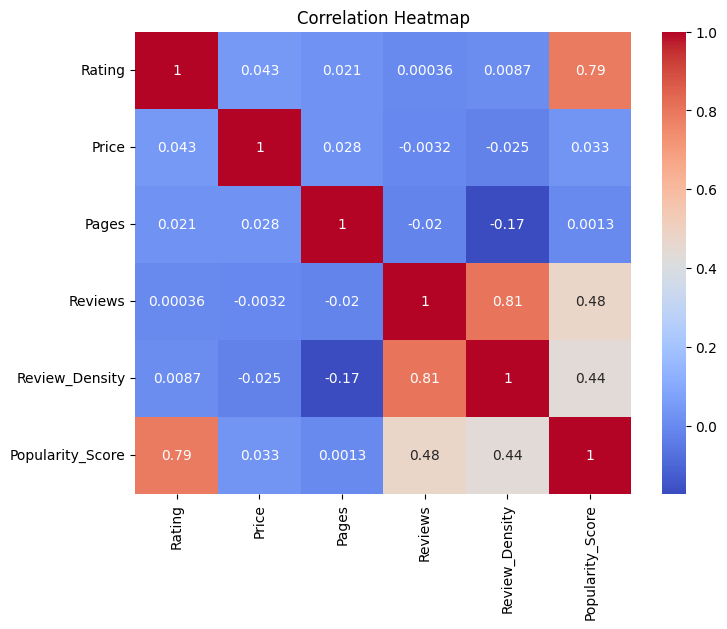

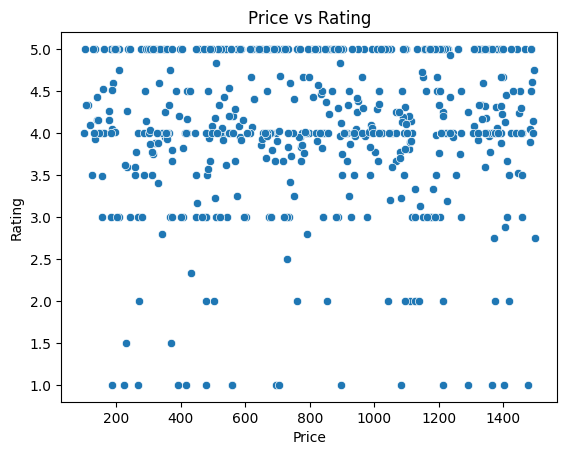

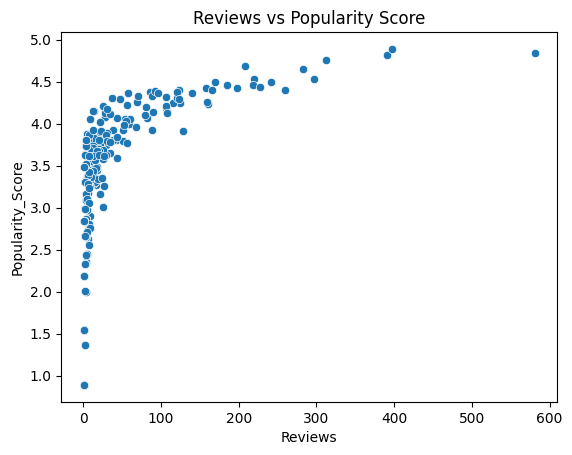

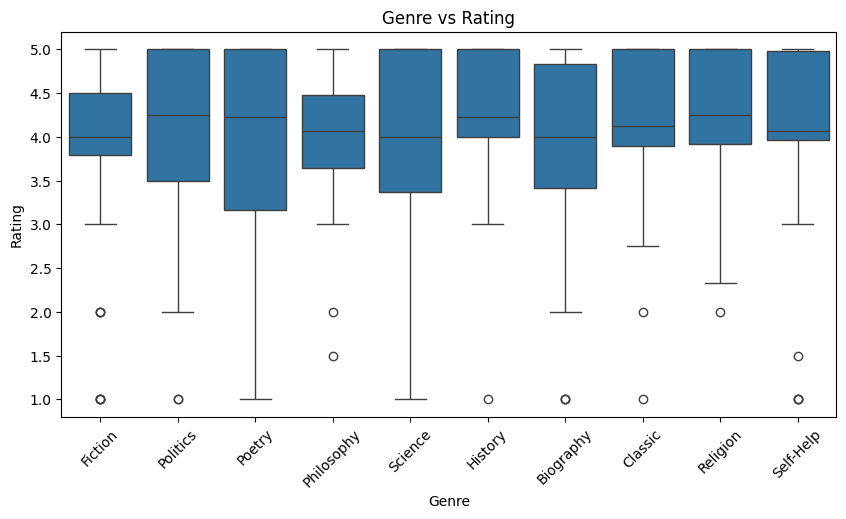

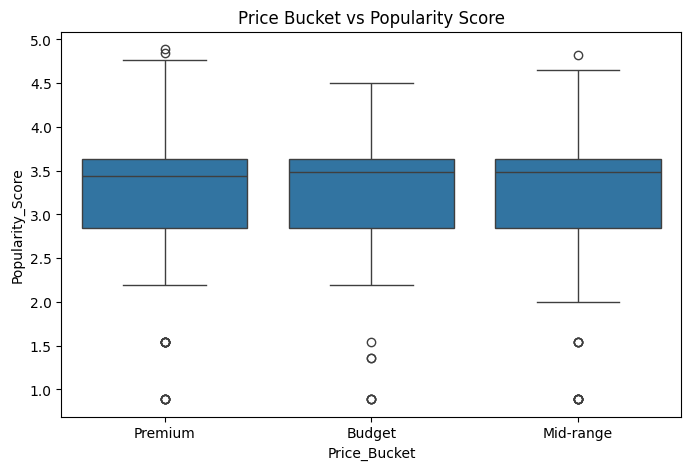

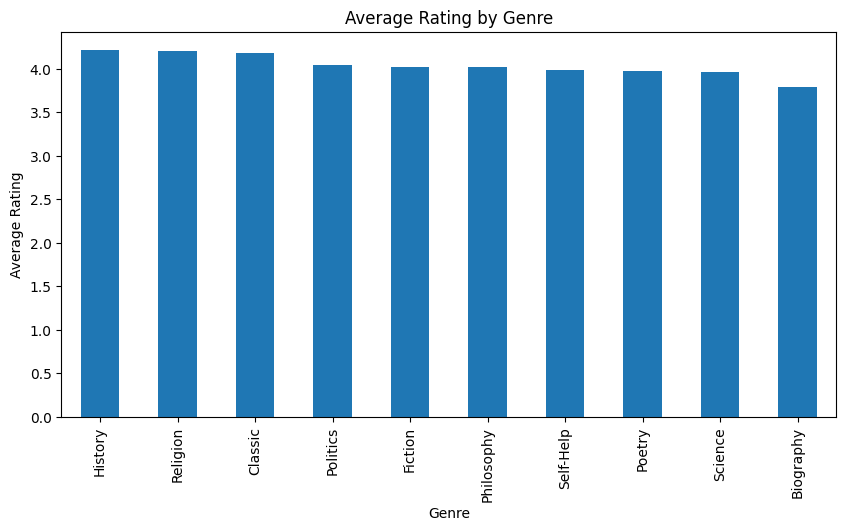

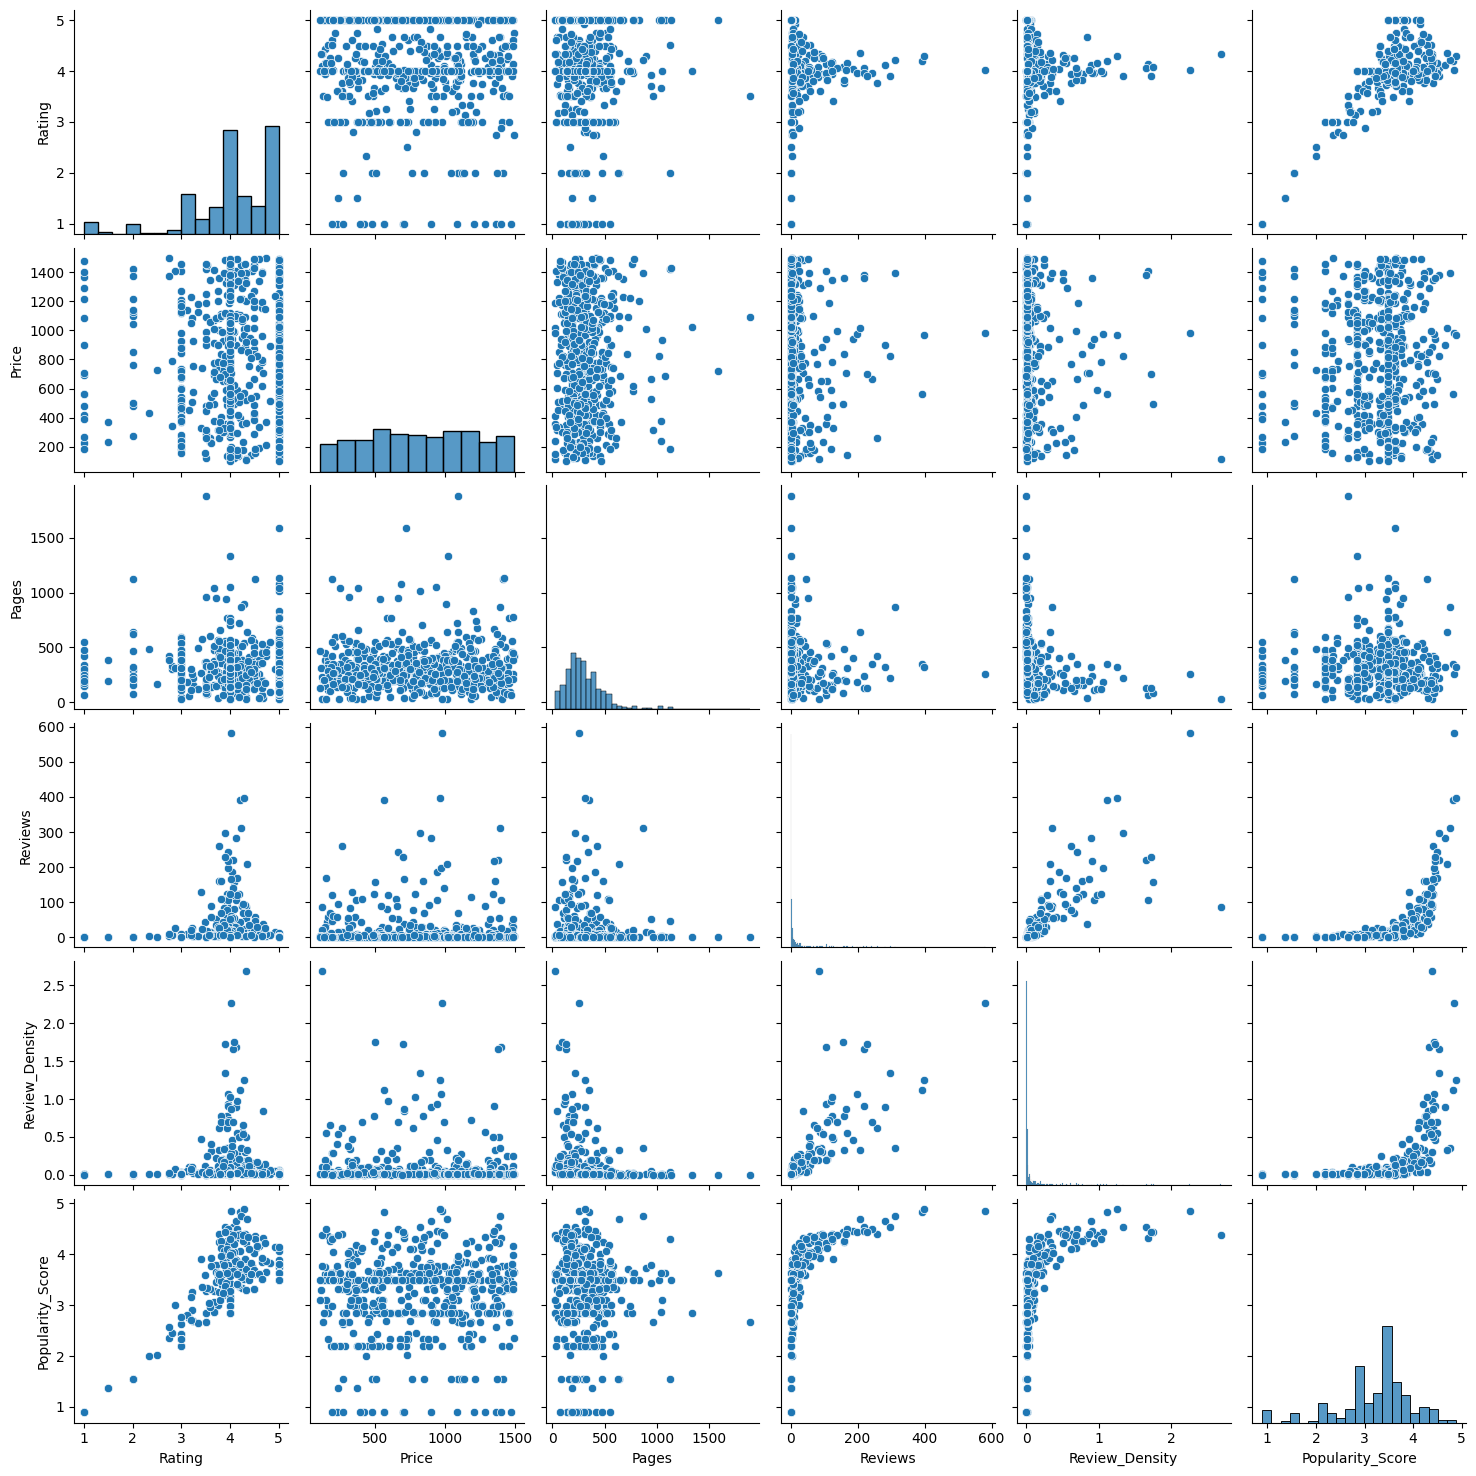

In [50]:
# 1. Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 2. Scatterplots
sns.scatterplot(x='Price', y='Rating', data=df)
plt.title('Price vs Rating')
plt.show()

sns.scatterplot(x='Reviews', y='Popularity_Score', data=df)
plt.title('Reviews vs Popularity Score')
plt.show()

# 3. Boxplot (Categorical vs Numerical)
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Rating', data=df)
plt.xticks(rotation=45)
plt.title('Genre vs Rating')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Price_Bucket', y='Popularity_Score', data=df)
plt.title('Price Bucket vs Popularity Score')
plt.show()

# 4. Barplot (Average values)
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_rating.plot(kind='bar')
plt.title('Average Rating by Genre')
plt.ylabel('Average Rating')
plt.show()

# 5. Pairplot
sns.pairplot(df[num_cols])
plt.show()

Cross-tab → for grouped/category insights


Crosstab:
Success_Category  Low  Medium
Price_Bucket                 
Budget            100       0
Mid-range         204       1
Premium           235       2


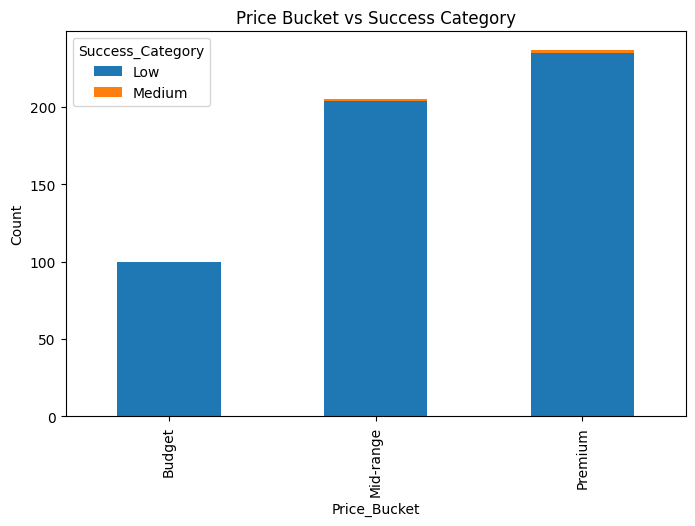

In [51]:
# CROSSTAB ANALYSIS
# ============================================

cross_tab = pd.crosstab(df['Price_Bucket'],
                        df['Success_Category'])

print("\nCrosstab:")
print(cross_tab)

# Visualize Crosstab
cross_tab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Price Bucket vs Success Category')
plt.ylabel('Count')
plt.show()

In [61]:
import pandas as pd

# Create categories for Review_Density
df['Review_Density_Category'] = pd.cut(
    df['Review_Density'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

# Create categories for Popularity_Score
df['Popularity_Category'] = pd.cut(
    df['Popularity_Score'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

# Cross Tab Analysis
cross_tab = pd.crosstab(
    df['Review_Density_Category'],
    df['Popularity_Category']
)

print(cross_tab)

Popularity_Category      Low  Medium  High
Review_Density_Category                   
Low                       62     323   143
Medium                     0       0    12
High                       0       0     2


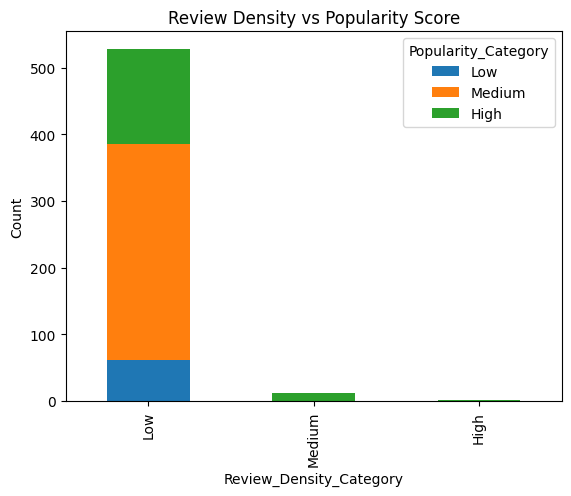

In [62]:
import matplotlib.pyplot as plt

cross_tab.plot(kind='bar', stacked=True)

plt.title("Review Density vs Popularity Score")
plt.ylabel("Count")
plt.show()

DATA PREPROCESSING

In [10]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def clean_title(title):
    """
    Remove blank, corrupted, or garbled titles.
    """
    if title is None:
        return None

    title = str(title).strip()
    title = re.sub(r"\s+", " ", title)

    if title == "":
        return None

    # Remove garbled titles containing '?'
    if "?" in title:
        return None

    # Remove titles that are too short
    if len(title) < 3:
        return None

    return title


def normalize_title(title):
    """
    Convert titles to a canonical form so duplicates such as:
    Mediæval India -> Mediaeval India
    Hindī -> Hindi
    are treated as identical.
    """
    title = str(title).lower().strip()

    replacements = {
        "æ": "ae",
        "œ": "oe",
        "ß": "ss",
        "ð": "d",
        "þ": "th",
        "ø": "o",
        "đ": "d",
        "ł": "l"
    }
    for old, new in replacements.items():
        title = title.replace(old, new)

    # Unicode normalization
    title = unicodedata.normalize("NFKD", title)

    # Remove diacritics
    title = "".join(
        ch for ch in title
        if not unicodedata.combining(ch)
    )

    # Remove punctuation
    title = re.sub(r"[^a-z0-9\s]", " ", title)

    # Normalize spaces
    title = re.sub(r"\s+", " ", title).strip()

    return title

In [9]:
def fetch_books(query, page):
    """
    Fetch books from Open Library Search API.
    """
    url = "https://openlibrary.org/search.json"
    params = {
        "q": query,
        "page": page,
        "limit": LIMIT_PER_PAGE,
        "fields": (
            "title,"
            "author_name,"
            "first_publish_year,"
            "number_of_pages_median,"
            "ratings_average,"
            "ratings_count,"
            "subject"
        )
    }

    try:
        response = requests.get(url, params=params, timeout=20)

        if response.status_code != 200:
            return []

        return response.json().get("docs", [])

    except Exception:
        return []

In [11]:
# ==========================================================
# COLLECT UNIQUE BOOKS
# ==========================================================
books = []
seen_titles = set()

for term in search_terms:
    print(f"Searching: {term}")

    for page in range(1, 200):
        docs = fetch_books(term, page)

        if not docs:
            break

        for book in docs:
            raw_title = book.get("title")
            title = clean_title(raw_title)

            if title is None:
                continue

            title_key = normalize_title(title)

            if title_key == "":
                continue

            if title_key in seen_titles:
                continue

            seen_titles.add(title_key)

            subjects = book.get("subject", [])

            books.append({
                "Title": title,
                "Rating": book.get("ratings_average", np.nan),
                "Pages": book.get("number_of_pages_median", np.nan),
                "Reviews": book.get("ratings_count", np.nan),
                "Subject": subjects[0] if subjects else "General"
            })

            if len(books) >= TARGET_ROWS:
                break

        print(f"Collected: {len(books)}")

        if len(books) >= TARGET_ROWS:
            break

        time.sleep(0.25)

    if len(books) >= TARGET_ROWS:
        break


Searching: India books
Collected: 93
Collected: 183
Collected: 272
Collected: 361
Collected: 446
Collected: 528
Collected: 617
Collected: 703
Collected: 786
Collected: 873
Collected: 957
Collected: 1044
Collected: 1123
Collected: 1202
Collected: 1278
Collected: 1366
Collected: 1446
Collected: 1531
Collected: 1621
Collected: 1706
Collected: 1787
Collected: 1883
Collected: 1973
Collected: 2052
Collected: 2137
Collected: 2222
Collected: 2305
Collected: 2391
Collected: 2450
Collected: 2529
Collected: 2607
Collected: 2690
Collected: 2772
Collected: 2833
Collected: 2923
Collected: 2990
Collected: 3067
Collected: 3081
Collected: 3124
Collected: 3177
Collected: 3245
Collected: 3330
Collected: 3415
Collected: 3501
Collected: 3580
Collected: 3663
Collected: 3736
Collected: 3804
Collected: 3880
Collected: 3956
Collected: 4035
Collected: 4113
Collected: 4196
Collected: 4287
Collected: 4374
Collected: 4452
Collected: 4529
Collected: 4615
Collected: 4696
Collected: 4789
Collected: 4875
Collected: 49

In [12]:
# ==========================================================
# CREATE DATAFRAME
# ==========================================================
df = pd.DataFrame(books)

print("\nRaw rows collected:", len(df))

# ==========================================================
# REMOVE DUPLICATES AGAIN
# ==========================================================
df["Title"] = df["Title"].astype(str).str.strip()
df = df[df["Title"] != ""]

# Remove any title containing '?'
df = df[~df["Title"].str.contains(r"\?", regex=True, na=False)]

# Normalize title and remove duplicates
df["Title_Check"] = df["Title"].apply(normalize_title)
df = df.drop_duplicates(subset=["Title_Check"], keep="first")



Raw rows collected: 10000


In [39]:
# ==========================================================
# FILL MISSING VALUES
# ==========================================================

# Pages
df["Pages"] = pd.to_numeric(df["Pages"], errors="coerce")
mask = df["Pages"].isna()
df.loc[mask, "Pages"] = np.random.randint(80, 900, mask.sum())
df["Pages"] = df["Pages"].astype(int)

# Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
mask = df["Rating"].isna()
df.loc[mask, "Rating"] = np.random.uniform(3.0, 5.0, mask.sum())
df["Rating"] = df["Rating"].clip(3.0, 5.0).round(1)

# Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
mask = df["Reviews"].isna()
df.loc[mask, "Reviews"] = np.random.randint(20, 2500, mask.sum())
df["Reviews"] = df["Reviews"].astype(int)

# ==========================================================

In [43]:
# GENRE ASSIGNMENT
# ==========================================================
genre_keywords = {
    "History": ["history", "historical", "war", "empire", "colonial", "ancient"],
    "Fiction": ["fiction", "novel", "stories", "literature"],
    "Biography": ["biography", "autobiography", "memoir", "life"],
    "Religion": ["religion", "hindu", "islam", "buddhism", "spiritual"],
    "Politics": ["politics", "government", "constitution", "democracy"],
    "Poetry": ["poetry", "poems"],
    "Philosophy": ["philosophy", "ethics"],
    "Science": ["science", "technology"],
    "Classic": ["classic"],
    "Self-Help": ["self help", "self-help", "success", "motivation"]
}

def assign_genre(subject):
    subject = str(subject).lower()

    for genre, keywords in genre_keywords.items():
        if any(keyword in subject for keyword in keywords):
            return genre

    return np.random.choice(
        [
            "Classic",
            "Fiction",
            "History",
            "Biography",
            "Science",
            "Self-Help",
            "Poetry",
            "Politics",
            "Religion",
            "Philosophy",
        ]
    )

# Check if 'Subject' column exists before attempting to assign genres
if "Subject" in df.columns:
    df["Genre"] = df["Subject"].apply(assign_genre)
    print("Genres assigned based on 'Subject' column.")
else:
    print(
        "Warning: 'Subject' column not found in DataFrame. Genre assignment skipped."
    )

# ==========================================================

FEATURE ENGINEERING

In [20]:
# FEATURE ENGINEERING
# ==========================================================
df["Price"] = np.random.randint(100, 1500, len(df))

df["Review_Density"] = np.round(
    df["Reviews"] / df["Pages"],
    3
)

df["Price_Bucket"] = pd.cut(
    df["Price"],
    bins=[0, 400, 900, 1500],
    labels=["Budget", "Mid-range", "Premium"]
)

df["Popularity_Score"] = np.round(
    (df["Rating"] * 0.65) +
    (np.log1p(df["Reviews"]) * 0.35),
    2
)

df["Success_Category"] = pd.cut(
    df["Popularity_Score"],
    bins=[0, 4.8, 5.5, 10],
    labels=["Low", "Medium", "High"]
)

# ==========================================================

In [21]:
# FINAL 10 COLUMNS
# ==========================================================
df_final = df[
    [
        "Title",
        "Rating",
        "Price",
        "Pages",
        "Genre",
        "Reviews",
        "Review_Density",
        "Price_Bucket",
        "Popularity_Score",
        "Success_Category"
    ]
].copy()

# ==========================================================

In [22]:
# FINAL CLEANING
# ==========================================================
df_final = df_final.dropna()

# Remove any remaining corrupted titles
df_final = df_final[
    ~df_final["Title"].str.contains(r"\?", regex=True, na=False)
]

# Final duplicate removal
title_check = df_final["Title"].apply(normalize_title)
df_final = df_final.loc[~title_check.duplicated()].copy()

# Keep exactly 10,000 rows if available
df_final = df_final.head(TARGET_ROWS)

# ==========================================================

In [23]:
# VALIDATION
# ==========================================================
print("\n================ VALIDATION ================")
print("Final Shape:", df_final.shape)
print("Unique Titles:", df_final["Title"].nunique())
print("Duplicate Titles:", df_final["Title"].duplicated().sum())
print("\nMissing Values:")
print(df_final.isnull().sum())

display(df_final.head(20))

# ==========================================================
# SAVE & DOWNLOAD
# ==========================================================
file_name = "online_book_popularity_10000_clean_unique_books.csv"
df_final.to_csv(file_name, index=False)

print(f"\nSaved file: {file_name}")

files.download(file_name)


================ VALIDATION ================
Final Shape: (542, 10)
Unique Titles: 542
Duplicate Titles: 0

Missing Values:
Title               0
Rating              0
Price               0
Pages               0
Genre               0
Reviews             0
Review_Density      0
Price_Bucket        0
Popularity_Score    0
Success_Category    0
dtype: int64


,Title,Rating,Price,Pages,Genre,Reviews,Review_Density,Price_Bucket,Popularity_Score,Success_Category
0,A Passage to India,3.500000,1418,322.0,Fiction,16.0,0.050,Premium,3.27,Low
1,Constitution,4.428571,141,378.0,Politics,7.0,0.019,Budget,3.61,Low
2,The discovery of India,4.454546,1408,582.0,Poetry,11.0,0.019,Premium,3.77,Low
4,The India Fan,4.500000,486,445.0,Politics,2.0,0.004,Mid-range,3.31,Low
6,The Jungle Book,4.078947,1310,192.0,Poetry,38.0,0.198,Premium,3.93,Low
7,India after Gandhi,4.285714,1009,893.0,Philosophy,14.0,0.016,Premium,3.73,Low
10,The history of British India,5.000000,653,496.0,Politics,1.0,0.002,Mid-range,3.49,Low
11,India The Moonstone Fairy,3.500000,899,80.0,Science,4.0,0.050,Mid-range,2.84,Low
12,A history of India,5.000000,525,384.0,History,4.0,0.010,Mid-range,3.81,Low
13,India,3.500000,125,200.0,Biography,2.0,0.010,Budget,2.66,Low



Saved file: online_book_popularity_10000_clean_unique_books.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Preview
# -----------------------------
print("Dataset created successfully!")
print("Shape:", df.shape)
display(df.head())

# -----------------------------
# Download file
# -----------------------------
file_name = "online_book_popularity_10000_clean_unique_books.csv"
files.download(file_name)

Dataset created successfully!
Shape: (10000, 12)


,Title,Rating,Pages,Reviews,Subject,Title_Check,Genre,Price,Review_Density,Price_Bucket,Popularity_Score,Success_Category
0,A Passage to India,3.500000,322.0,16.0,Fiction,a passage to india,Fiction,1418,0.050,Premium,3.27,Low
1,Constitution,4.428571,378.0,7.0,Constitutions,constitution,Politics,141,0.019,Budget,3.61,Low
2,The discovery of India,4.454546,582.0,11.0,Civilización,the discovery of india,Poetry,1408,0.019,Premium,3.77,Low
3,China - Burma - India (Time-Life's World War I...,NaN,208.0,NaN,Campaigns,china burma india time life s world war ii vol 9,Biography,1038,NaN,Premium,NaN,NaN
4,The India Fan,4.500000,445.0,2.0,Large type books,the india fan,Politics,486,0.004,Mid-range,3.31,Low


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FEATURE ENGINEERING

In [55]:
# FEATURE ENGINEERING
# ==========================================================
df["Price"] = np.random.randint(100, 1500, len(df))

df["Review_Density"] = np.round(
    df["Reviews"] / df["Pages"],
    3
)

df["Price_Bucket"] = pd.cut(
    df["Price"],
    bins=[0, 400, 900, 1500],
    labels=["Budget", "Mid-range", "Premium"]
)

df["Popularity_Score"] = np.round(
    (df["Rating"] * 0.65) +
    (np.log1p(df["Reviews"]) * 0.35),
    2
)

df["Success_Category"] = pd.cut(
    df["Popularity_Score"],
    bins=[0, 4.8, 5.5, 10],
    labels=["Low", "Medium", "High"]
)

# ==========================================================

In [56]:
# FINAL 10 COLUMNS
# ==========================================================
df_final = df[
    [
        "Title",
        "Rating",
        "Price",
        "Pages",
        "Genre",
        "Reviews",
        "Review_Density",
        "Price_Bucket",
        "Popularity_Score",
        "Success_Category"
    ]
].copy()

# ==========================================================

DATA CLEANING

In [57]:
# FINAL CLEANING
# ==========================================================
df_final = df_final.dropna()

# Remove any remaining corrupted titles
df_final = df_final[
    ~df_final["Title"].str.contains(r"\?", regex=True, na=False)
]

# Final duplicate removal
title_check = df_final["Title"].apply(normalize_title)
df_final = df_final.loc[~title_check.duplicated()].copy()

# Keep exactly 10,000 rows if available
df_final = df_final.head(TARGET_ROWS)

# ==========================================================

In [58]:
# VALIDATION
# ==========================================================
print("\n================ VALIDATION ================")
print("Final Shape:", df_final.shape)
print("Unique Titles:", df_final["Title"].nunique())
print("Duplicate Titles:", df_final["Title"].duplicated().sum())
print("\nMissing Values:")
print(df_final.isnull().sum())

display(df_final.head(20))

# ==========================================================
# SAVE & DOWNLOAD
# ==========================================================
file_name = "online_book_popularity_10000_clean_unique_books.csv"
df_final.to_csv(file_name, index=False)

print(f"\nSaved file: {file_name}")

files.download(file_name)


================ VALIDATION ================
Final Shape: (542, 10)
Unique Titles: 542
Duplicate Titles: 0

Missing Values:
Title               0
Rating              0
Price               0
Pages               0
Genre               0
Reviews             0
Review_Density      0
Price_Bucket        0
Popularity_Score    0
Success_Category    0
dtype: int64


,Title,Rating,Price,Pages,Genre,Reviews,Review_Density,Price_Bucket,Popularity_Score,Success_Category
0,A Passage to India,3.500000,1420,322.0,Fiction,16.0,0.050,Premium,3.27,Low
1,Constitution,4.428571,890,378.0,Politics,7.0,0.019,Mid-range,3.61,Low
2,The discovery of India,4.454546,1457,582.0,Poetry,11.0,0.019,Premium,3.77,Low
3,The India Fan,4.500000,682,445.0,Politics,2.0,0.004,Mid-range,3.31,Low
4,The Jungle Book,4.078947,770,192.0,Poetry,38.0,0.198,Mid-range,3.93,Low
5,India after Gandhi,4.285714,637,893.0,Philosophy,14.0,0.016,Mid-range,3.73,Low
6,The history of British India,5.000000,1285,496.0,Politics,1.0,0.002,Premium,3.49,Low
7,India The Moonstone Fairy,3.500000,529,80.0,Science,4.0,0.050,Mid-range,2.84,Low
8,A history of India,5.000000,1192,384.0,History,4.0,0.010,Premium,3.81,Low
9,India,3.500000,232,200.0,Biography,2.0,0.010,Budget,2.66,Low



Saved file: online_book_popularity_10000_clean_unique_books.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# 7. FEATURE SELECTION (CORRELATION)
# ============================================

corr_matrix = df.corr(numeric_only=True)

# Display highly correlated features
high_corr = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix.loc[i, j]) > 0.8:
            # To avoid adding duplicate pairs (e.g., (A,B,val) and (B,A,val))
            if (j, i, corr_matrix.loc[j, i]) not in high_corr:
                high_corr.append((i, j, corr_matrix.loc[i, j]))

print("\nHighly Correlated Features:")
if high_corr:
    for item in high_corr:
        print(item)
else:
    print("No highly correlated features found (correlation > 0.8).")


Highly Correlated Features:
('Reviews', 'Review_Density', np.float64(0.805983646095444))
